# 문제1-다: 동일한 상위2 WIS 앙상블의 트리 설정 튜닝

5개 후보, 입력, 예측구간, 상위2개 선택 및 역WIS 분위수 가중평균을 유지합니다. RF/ET 분할 설정3개만 과거 검증WIS로 비교합니다. 증가율 변수나 지수 성장 가정을 추가하지 않습니다.

RUN_SEARCH=True는3개 설정을 비교하며 제공 환경에서 총 약2분15초입니다. False이면 확인된 최선 설정으로 약53초에 실행합니다. DATA_PATH와 TEAM_ID를 수정한 뒤 전체 실행하세요. 검증WIS는 설정·모델 선택에 사용한 진단점수이며 독립 평가가 아닙니다. 미래 성능이나 계속 상승을 보장하지 않습니다.


후보 모델을 RF_delta, ET_delta, HGB_delta, Ridge_delta, Analog 5개로 통일했습니다. 이 중 검증 WIS 상위 2개만 역WIS 가중치로 앙상블합니다. GB의 정확한 구현 명칭은 HGB입니다. 기존에 제외된 후보가 상위 2개에 포함되지 않았다면 같은 실행 환경에서 결과가 유지됩니다.


| 후보 | 구현 | 예측 대상 |
|---|---|---|
| RF_delta | RandomForestRegressor | 현재 대비 향후 log1p(ILI) 변화량 |
| ET_delta | ExtraTreesRegressor | 현재 대비 향후 log1p(ILI) 변화량 |
| HGB_delta | HistGradientBoostingRegressor | 현재 대비 향후 log1p(ILI) 변화량 |
| Ridge_delta | StandardScaler + Ridge | 현재 대비 향후 log1p(ILI) 변화량 |
| Analog | 유사한 과거 입력 15개를 거리 가중 평균 | 과거의 log1p(ILI) 변화량을 현재에 적용 |

5개 후보 모두를 평균하는 방식이 아니라, 기점별 검증 WIS가 가장 작은 2개를 선택해 1/WIS를 정규화한 가중치로 같은 예측 분위수를 평균합니다.


In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

SEED = 2026
TOP_K = 2
WEIGHT_POWER = 1.0
WEIGHT_EPSILON = 1e-8
ENSEMBLE_NAME = "Ensemble_top2_inverse_WIS"
QUANTILES = np.array([0.025, 0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
ORIGINS = {'1C': 202639}
CANDIDATES = ['RF_delta', 'ET_delta', 'HGB_delta', 'Ridge_delta', 'Analog']

def load_data(path):
    df = pd.read_excel(path)
    df = df.sort_values('년주').reset_index(drop=True)
    assert df['년주'].is_unique
    assert df['ILI'].notna().all()
    return df

def features(df):
    y = np.log1p(df['ILI'].to_numpy(float))
    rows = []
    for t in range(12, len(df)):
        w = float(df.iloc[t]['주차'])
        v = list(y[t - np.arange(8)])
        v += [y[t] - y[t - k] for k in [1, 2, 3, 4, 8, 12]]
        v += [float(np.mean(y[t - k + 1:t + 1])) for k in [3, 6, 12]]
        v += [float(np.std(y[t - 5:t + 1])), np.sin(2 * np.pi * w / 52.18), np.cos(2 * np.pi * w / 52.18)]
        for col in ['전체 검출률(%)', 'A(H1N1)pdm09', 'A(H3N2)', 'B']:
            z = np.log1p(df[col].to_numpy(float))
            v += [z[t], z[t - 1], z[t] - z[t - 2]]
        rows.append(v)
    return np.asarray(rows), y

def train_predict(df, candidate_names=None):
    # df contains observations through this origin only.
    x, y = features(df)
    t = np.arange(12, len(df) - 5)
    keep = ~df.iloc[t + 5]['년주'].between(202010, 202220).to_numpy()
    t = t[keep]
    xx = x[t - 12]
    future = np.stack([y[t + h] for h in range(1, 6)], axis=1)
    delta = future - y[t, None]
    weights = np.exp(-0.035 * (len(df) - 1 - t) / 52)
    xp = x[-1:]
    result = {}
    names = CANDIDATES if candidate_names is None else candidate_names
    for name in names:
        if name in ('RF_delta', 'ET_delta'):
            cls = RandomForestRegressor if name.startswith('RF') else ExtraTreesRegressor
            model = cls(n_estimators=100, min_samples_leaf=TREE_MIN_LEAF, max_features=TREE_MAX_FEATURES, random_state=SEED, n_jobs=1)
            model.fit(xx, delta, sample_weight=weights)
            pred = model.predict(xp)[0] + y[-1]
        elif name == 'HGB_delta':
            pred = []
            for h in range(5):
                model = HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=7, min_samples_leaf=12, learning_rate=0.05, l2_regularization=8, random_state=SEED)
                model.fit(xx, delta[:, h], sample_weight=weights)
                pred.append(model.predict(xp)[0] + y[-1])
            pred = np.asarray(pred)
        elif name == 'Ridge_delta':
            model = make_pipeline(StandardScaler(), Ridge(alpha=100))
            model.fit(xx, delta)
            pred = model.predict(xp)[0] + y[-1]
        elif name == 'Analog':
            # Compare recent trajectory, season, and pathogen indicators.
            scale = np.maximum(np.std(xx, axis=0), 0.15)
            dist = cdist(xp / scale, xx / scale)[0]
            idx = np.argsort(dist)[:15]
            ww = np.exp(-dist[idx] / max(np.median(dist[idx]), 0.1)) * weights[idx]
            pred = y[-1] + np.average(delta[idx], axis=0, weights=ww)
        else:
            raise ValueError(f'지원하지 않는 후보 모델: {name}')
        result[name] = np.clip(pred, 0, np.log1p(max(df['ILI'].max() * 3, 30)))
    return result

def wis(q, actual):
    score = 0.5 * np.abs(actual - q[:, 3])
    for alpha, lo, hi in [(0.05, 0, 6), (0.20, 1, 5), (0.50, 2, 4)]:
        l = q[:, lo]
        u = q[:, hi]
        interval = u - l + 2 / alpha * np.maximum(l - actual, 0) + 2 / alpha * np.maximum(actual - u, 0)
        score += alpha / 2 * interval
    return score / 3.5

def intervals(center, residual):
    offsets = np.quantile(residual, QUANTILES, axis=0).T
    # Keep the model forecast as the median; center empirical errors.
    offsets -= offsets[:, 3:4]
    return np.maximum(0, np.expm1(center[:, None] + offsets))

def baseline(df):
    yy = df['ILI'].to_numpy(float)
    q = []
    for h in range(1, 6):
        change = yy[h:] - yy[:-h]
        change = np.r_[change, -change]
        q.append(np.maximum(0, yy[-1] + np.quantile(change, QUANTILES)))
    return np.asarray(q)


# Fast, chronological validation: first 8 origins calibrate; remaining 24 rank models.
VALIDATION_ORIGINS = 32
MIN_CALIBRATION_ORIGINS = 8
VALIDATION_STRIDE = 6
TEAM_ID = 'REPLACE_TEAM_ID'

def forecast_task1c(data_path, output_dir):
    import time
    started = time.perf_counter()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    data = load_data(data_path)
    required = ['년주', '주차', 'ILI', '전체 검출률(%)', 'A(H1N1)pdm09', 'A(H3N2)', 'B']
    if data[required].isna().any().any():
        raise ValueError('필수 입력 열에 결측값이 있습니다.')
    if not np.isfinite(data[required].to_numpy(float)).all():
        raise ValueError('필수 입력 열에 비유한 값이 있습니다.')
    if (data[['ILI', '전체 검출률(%)', 'A(H1N1)pdm09', 'A(H3N2)', 'B']] < 0).any().any():
        raise ValueError('ILI와 검출률은 음수일 수 없습니다.')
    origin = int(data['년주'].iloc[-1])
    if origin != 202639:
        raise ValueError(f'이 노트북은 문제 1-다 기점 2026-39용입니다. 데이터 마지막 주차: {origin}')
    valid = np.arange(len(data) - 6, 119, -VALIDATION_STRIDE)[::-1]
    valid = valid[~data.iloc[valid]['년주'].between(202010, 202225).to_numpy()]
    valid = valid[-VALIDATION_ORIGINS:]
    if len(valid) <= MIN_CALIBRATION_ORIGINS + 5:
        raise ValueError('순차 검증을 위한 과거 자료가 부족합니다.')
    errors = {name: [] for name in CANDIDATES}
    scores = {name: [] for name in CANDIDATES}
    raw_points = {name: [] for name in CANDIDATES}
    actuals = []
    scored_quantiles = {name: [] for name in CANDIDATES}
    audit = []
    for i, t in enumerate(valid):
        prefix = data.iloc[:t + 1].copy()
        points = train_predict(prefix)
        actual = data.iloc[t + 1:t + 6]['ILI'].to_numpy(float)
        if i >= MIN_CALIBRATION_ORIGINS:
            actuals.append(actual)
            for name in CANDIDATES:
                q = intervals(points[name], np.asarray(errors[name]))
                score = wis(q, actual)
                scores[name].append(float(score.mean()))
                scored_quantiles[name].append(q)
                raw_points[name].append(np.expm1(points[name]))
                audit.append({'validation_origin': int(data.iloc[t]['년주']), 'model': name, 'calibration_origin_count': i, 'latest_calibration_target': int(data.iloc[valid[i - 1] + 5]['년주']), 'WIS': float(score.mean())})
        for name in CANDIDATES:
            errors[name].append(np.log1p(actual) - points[name])
        print(f'순차 검증 {i + 1}/{len(valid)} 완료', flush=True)
    observed = np.asarray(actuals)
    records = []
    for name in CANDIDATES:
        rmse = np.sqrt(np.mean((np.asarray(raw_points[name]) - observed) ** 2))
        records.append({'model': name, 'validation_WIS': np.mean(scores[name]), 'validation_RMSE': rmse})
    ranking = pd.DataFrame(records).sort_values('validation_WIS', kind='stable').reset_index(drop=True)
    ranking['rank'] = np.arange(1, len(ranking) + 1)
    ranking['selected_for_ensemble'] = ranking['rank'] <= TOP_K
    ranking['ensemble_weight'] = 0.0
    selected = ranking.iloc[:TOP_K]
    inverse = 1 / np.maximum(selected['validation_WIS'].to_numpy(float), WEIGHT_EPSILON)
    weights = dict(zip(selected['model'], inverse / inverse.sum()))
    ranking.loc[:TOP_K - 1, 'ensemble_weight'] = list(weights.values())
    points = train_predict(data, list(weights))
    component_q = {name: intervals(points[name], np.asarray(errors[name])) for name in weights}
    final_q = sum(weight * component_q[name] for name, weight in weights.items())
    if not np.isfinite(final_q).all() or (final_q < 0).any() or (np.diff(final_q, axis=1) < -1e-10).any():
        raise ValueError('분위수 검증 실패')
    diagnostic_q = sum(weight * np.asarray(scored_quantiles[name]) for name, weight in weights.items())
    diagnostic_wis = np.mean([wis(q, y).mean() for q, y in zip(diagnostic_q, observed)])
    target_weeks = [f'2026-{week:02d}' for week in range(40, 45)]
    wide = pd.DataFrame({'origin': '1C', 'origin_week': '2026-39', 'target_week': target_weeks, 'horizon': np.arange(1, 6), 'model': ENSEMBLE_NAME, 'actual': np.nan})
    for k, quantile in enumerate(QUANTILES):
        wide[f'q{quantile:g}'] = final_q[:, k]
    rows = []
    for h, week in enumerate(target_weeks):
        for k, quantile in enumerate(QUANTILES):
            rows.append({'team_id': TEAM_ID, 'model_id': 'top2_inverse_wis_chronological_v2', 'task': '1C', 'origin': '2026-39', 'scenario_id': 'NA', 'target': 'ili', 'target_week': week, 'horizon': h + 1, 'quantile': quantile, 'value': final_q[h, k]})
    submission = pd.DataFrame(rows)
    assert len(submission) == 35 and not submission.duplicated(['task', 'origin', 'target_week', 'quantile']).any()
    assert np.isclose(sum(weights.values()), 1)
    audit = pd.DataFrame(audit)
    assert (audit['latest_calibration_target'] < audit['validation_origin']).all()
    ranking.to_csv(output_dir / 'validation_comparison.csv', index=False)
    ranking.iloc[:TOP_K].to_csv(output_dir / 'ensemble_weights.csv', index=False)
    audit.to_csv(output_dir / 'validation_audit.csv', index=False)
    wide.to_csv(output_dir / 'predictions.csv', index=False)
    submission.to_csv(output_dir / 'submission_1C_long.csv', index=False)
    component_rows = []
    for name in weights:
        for h in range(5):
            row = {'model': name, 'weight': weights[name], 'target_week': target_weeks[h], 'horizon': h + 1}
            row.update({f'q{quantile:g}': component_q[name][h, k] for k, quantile in enumerate(QUANTILES)})
            component_rows.append(row)
    pd.DataFrame(component_rows).to_csv(output_dir / 'component_predictions.csv', index=False)
    report = {'origin': '2026-39', 'members': weights, 'ensemble_validation_WIS_diagnostic': float(diagnostic_wis), 'runtime_seconds': time.perf_counter() - started, 'final_WIS': None, 'note': '선택 및 가중치 결정에 사용한 자료의 앙상블 점수는 독립 평가가 아닙니다. 40~44주 실제값이 없어 최종 WIS는 계산하지 않습니다.'}
    (output_dir / 'run_summary.json').write_text(json.dumps(report, ensure_ascii=False, indent=2))
    metadata = '''# 문제 1-다 모형 설명 및 변경 기록
기점: 2026-39. 목표: 2026-40~44. 대상: 300개소 기준 ILI.
새 2차 배포 자료의 ILI 및 전체·아형 검출률을 사용한다. ARI는 제외한다.
입력: log1p ILI 최근 8개 관측, 1/2/3/4/8/12주 차이, 3/6/12주 이동평균, 6주 표준편차, 주차 sin/cos 및 log1p 검출률의 현재·1주 전·2주 차이.
5개 후보: RF_delta, ET_delta, HGB_delta, Ridge_delta, Analog. HGB는 HistGradientBoostingRegressor이다.
검증 WIS 상위 2개를 선택하고 1/WIS 정규화 가중치로 같은 분위수를 평균한다. 혼합분포의 분위수 계산과는 다르다.
각 후보 PI는 과거 순차 검증의 지평별 로그 오차 경험 분위수로 계산하며, 오차 중앙값을 차감해 모델 점 예측을 유지한다. 정규분포 가정은 없다. 명목 95% PI의 실제 포함률은 보장되지 않는다.
1-나 대비 변경: 기점을 34주에서39주로 갱신하고 2차 배포본을 사용한다. 트리 160개를100개로 줄여 실행 시간을 줄인다. 기존 leave-one-out 오차 보정 대신 검증 기점 이전에 관측이 완료된 오차만 사용한다. 최근32개 검증 기점(6주 간격) 중 처음8개는 초기 보정, 이후24개로 순위를 계산한다.
코로나 저유행기 학습 제외 규칙과 기존 후보 하이퍼파라미터는 트리 수 이외 유지한다. 사람이 상승 형태로 값을 보정하거나 미래 정보를 입력하지 않는다. 추석 효과 변수나 검출률 미래값을 별도로 가정하지 않는다.
한계: 과거 성능이 미래 성능을 보장하지 않는다. 상위2개는 고정된 설정이며 최적 조합을 완전 탐색한 결과가 아니다. 검증자료에서 선택된 고정 모델·가중치로 계산한 앙상블 점수는 진단용이다.
실행: 데이터 엑셀과 노트북을 같은 폴더에 두고 TEAM_ID를 팀 번호로 수정한 뒤 전체 셀 실행. 제출용 장형 CSV는35행이다. 1-다의 최종 WIS는 향후 실제값 공개 후 평가한다.
LLM 사용: 코드 작성 및 구현 검토에 ChatGPT/Codex 사용. 데이터는 외부 공개하지 않는다.
'''
    (output_dir / 'model_metadata_1.md').write_text(metadata)
    print(ranking.round(4).to_string(index=False))
    print(wide[['target_week', 'q0.025', 'q0.5', 'q0.975']].round(3).to_string(index=False))
    print(f'실행 시간: {report["runtime_seconds"]:.1f}초', flush=True)
    return wide, ranking, report

def plot_task1c(data_path, output_dir, predictions):
    data = load_data(data_path)
    output_dir = Path(output_dir)
    n = min(20, len(data))
    history_x = np.arange(-n + 1, 1)
    future_x = predictions['horizon'].to_numpy(int)
    last = float(data['ILI'].iloc[-1])
    fig, ax = plt.subplots(figsize=(8, 3), dpi=300)
    ax.scatter(history_x, data['ILI'].iloc[-n:], color='black', s=16, label='Observed')
    ax.plot(np.r_[0, future_x], np.r_[last, predictions['q0.5']], color='blue', linewidth=2, label='Predicted')
    ax.fill_between(np.r_[0, future_x], np.r_[last, predictions['q0.025']], np.r_[last, predictions['q0.975']], color='blue', alpha=0.10, linewidth=0, label='95% PI')
    history_ticks = list(range(-n + 1, 1, 4))
    history_labels = [f'{int(value)//100}-{int(value)%100:02d}' for value in data['년주'].iloc[-n:]]
    ticks = history_ticks + [1, 5]
    labels = [history_labels[t + n - 1] for t in history_ticks] + [predictions['target_week'].iloc[0], predictions['target_week'].iloc[-1]]
    ax.set_xticks(ticks, labels, rotation=30, ha='right')
    ax.set_xlabel('Week', fontsize=12, fontweight='bold')
    ax.set_ylabel('ILI per 1,000 outpatients', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=7, loc='upper left', ncol=2)
    ax.set_ylim(0, max(float(data['ILI'].iloc[-n:].max()), float(predictions['q0.975'].max())) * 1.30)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(output_dir / 'forecast_1C.png', dpi=300)
    plt.close(fig)

TREE_MIN_LEAF = 1
TREE_MAX_FEATURES = 1.0
BEST_LEAF = 1
BEST_FEATURES = 1.0


In [2]:
# 수정할 설정
DATA_PATH = "인플루엔자 2차 학습 데이터_아형 검출률 추가.xlsx"
OUTPUT_DIR = Path("forecast_results_task1c_5models_tuned")
TEAM_ID = "REPLACE_TEAM_ID"
RUN_SEARCH = True

# 5개 후보·검증 기점·PI·상위2·역WIS 가중치는 그대로 유지합니다.
# 트리 분할 설정 3개만 비교합니다. 현재 예측의 상승 여부는 선택 기준이 아닙니다.
import shutil
configs = [(3, 0.8), (2, 1.0), (1, 1.0)]
if not RUN_SEARCH:
    configs = [(BEST_LEAF, BEST_FEATURES)]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
trial_records = []
for trial_id, (TREE_MIN_LEAF, TREE_MAX_FEATURES) in enumerate(configs):
    trial_dir = OUTPUT_DIR / f"trial_{trial_id}"
    trial_predictions, trial_ranking, trial_report = forecast_task1c(DATA_PATH, trial_dir)
    trial_records.append({"trial_id": trial_id, "min_samples_leaf": TREE_MIN_LEAF, "max_features": TREE_MAX_FEATURES, "validation_WIS_diagnostic": trial_report["ensemble_validation_WIS_diagnostic"], "median_h5": float(trial_predictions["q0.5"].iloc[-1]), "runtime_seconds": trial_report["runtime_seconds"]})
search_results = pd.DataFrame(trial_records).sort_values("validation_WIS_diagnostic", kind="stable").reset_index(drop=True)
selected = search_results.iloc[0]
selected_dir = OUTPUT_DIR / f"trial_{int(selected['trial_id'])}"
for source_file in selected_dir.iterdir():
    if source_file.is_file():
        shutil.copy2(source_file, OUTPUT_DIR / source_file.name)
search_results.to_csv(OUTPUT_DIR / "hyperparameter_search.csv", index=False)
predictions = pd.read_csv(OUTPUT_DIR / "predictions.csv")
ranking = pd.read_csv(OUTPUT_DIR / "validation_comparison.csv")
report = json.loads((OUTPUT_DIR / "run_summary.json").read_text())
metadata_path = OUTPUT_DIR / "model_metadata_1.md"
metadata_path.write_text(metadata_path.read_text() + f"\n추가 변경: RF/ET min_samples_leaf 및 max_features의3개 조합을 비교했다. 선택 설정: leaf={int(selected['min_samples_leaf'])}, max_features={selected['max_features']}. 선택 기준은 같은 검증 자료에서의 최종앙상블 WIS이며 독립적인 미래 평가가 아니다. 상승 방향 자체로 설정을 선택하지 않는다. 후보군5개, 입력, PI 및 역WIS 가중방식은 유지한다.\n")
display(search_results.round(4))


순차 검증 1/32 완료
순차 검증 2/32 완료
순차 검증 3/32 완료
순차 검증 4/32 완료
순차 검증 5/32 완료
순차 검증 6/32 완료
순차 검증 7/32 완료
순차 검증 8/32 완료
순차 검증 9/32 완료
순차 검증 10/32 완료
순차 검증 11/32 완료
순차 검증 12/32 완료
순차 검증 13/32 완료
순차 검증 14/32 완료
순차 검증 15/32 완료
순차 검증 16/32 완료
순차 검증 17/32 완료
순차 검증 18/32 완료
순차 검증 19/32 완료
순차 검증 20/32 완료
순차 검증 21/32 완료
순차 검증 22/32 완료
순차 검증 23/32 완료
순차 검증 24/32 완료
순차 검증 25/32 완료
순차 검증 26/32 완료
순차 검증 27/32 완료
순차 검증 28/32 완료
순차 검증 29/32 완료
순차 검증 30/32 완료
순차 검증 31/32 완료
순차 검증 32/32 완료
      model  validation_WIS  validation_RMSE  rank  selected_for_ensemble  ensemble_weight
   ET_delta          3.3202          10.8564     1                   True           0.5022
   RF_delta          3.3502          11.0569     2                   True           0.4978
  HGB_delta          3.4138          11.2989     3                  False           0.0000
Ridge_delta          4.3170          13.4737     4                  False           0.0000
     Analog          4.3298          13.3767     5                  False 

,trial_id,min_samples_leaf,max_features,validation_WIS_diagnostic,median_h5,runtime_seconds
0,2,1,1.0,3.1979,35.3572,60.1351
1,1,2,1.0,3.2298,34.5447,44.0341
2,0,3,0.8,3.3212,34.6952,34.0898


In [3]:
display(ranking.round(4))
display(predictions[["target_week", "q0.025", "q0.1", "q0.25", "q0.5", "q0.75", "q0.9", "q0.975"]].round(3))
print("최종 전향 WIS: 실제값 공개 후 계산 가능")
print("팀 번호를 설정한 뒤 submission_1C_long.csv를 제출하세요.")


,model,validation_WIS,validation_RMSE,rank,selected_for_ensemble,ensemble_weight
0,ET_delta,3.1712,10.1608,1,True,0.5101
1,RF_delta,3.3019,10.9345,2,True,0.4899
2,HGB_delta,3.4138,11.2989,3,False,0.0000
3,Ridge_delta,4.3170,13.4737,4,False,0.0000
4,Analog,4.3298,13.3767,5,False,0.0000


,target_week,q0.025,q0.1,q0.25,q0.5,q0.75,q0.9,q0.975
0,2026-40,27.904,29.245,32.426,34.904,41.895,46.241,52.857
1,2026-41,27.408,30.452,33.674,38.164,47.562,58.668,71.844
2,2026-42,24.725,27.435,31.804,39.281,52.007,64.507,95.060
3,2026-43,17.676,21.841,26.936,37.931,50.762,67.382,98.958
4,2026-44,16.585,17.801,23.886,35.357,50.060,65.468,95.798


최종 전향 WIS: 실제값 공개 후 계산 가능
팀 번호를 설정한 뒤 submission_1C_long.csv를 제출하세요.


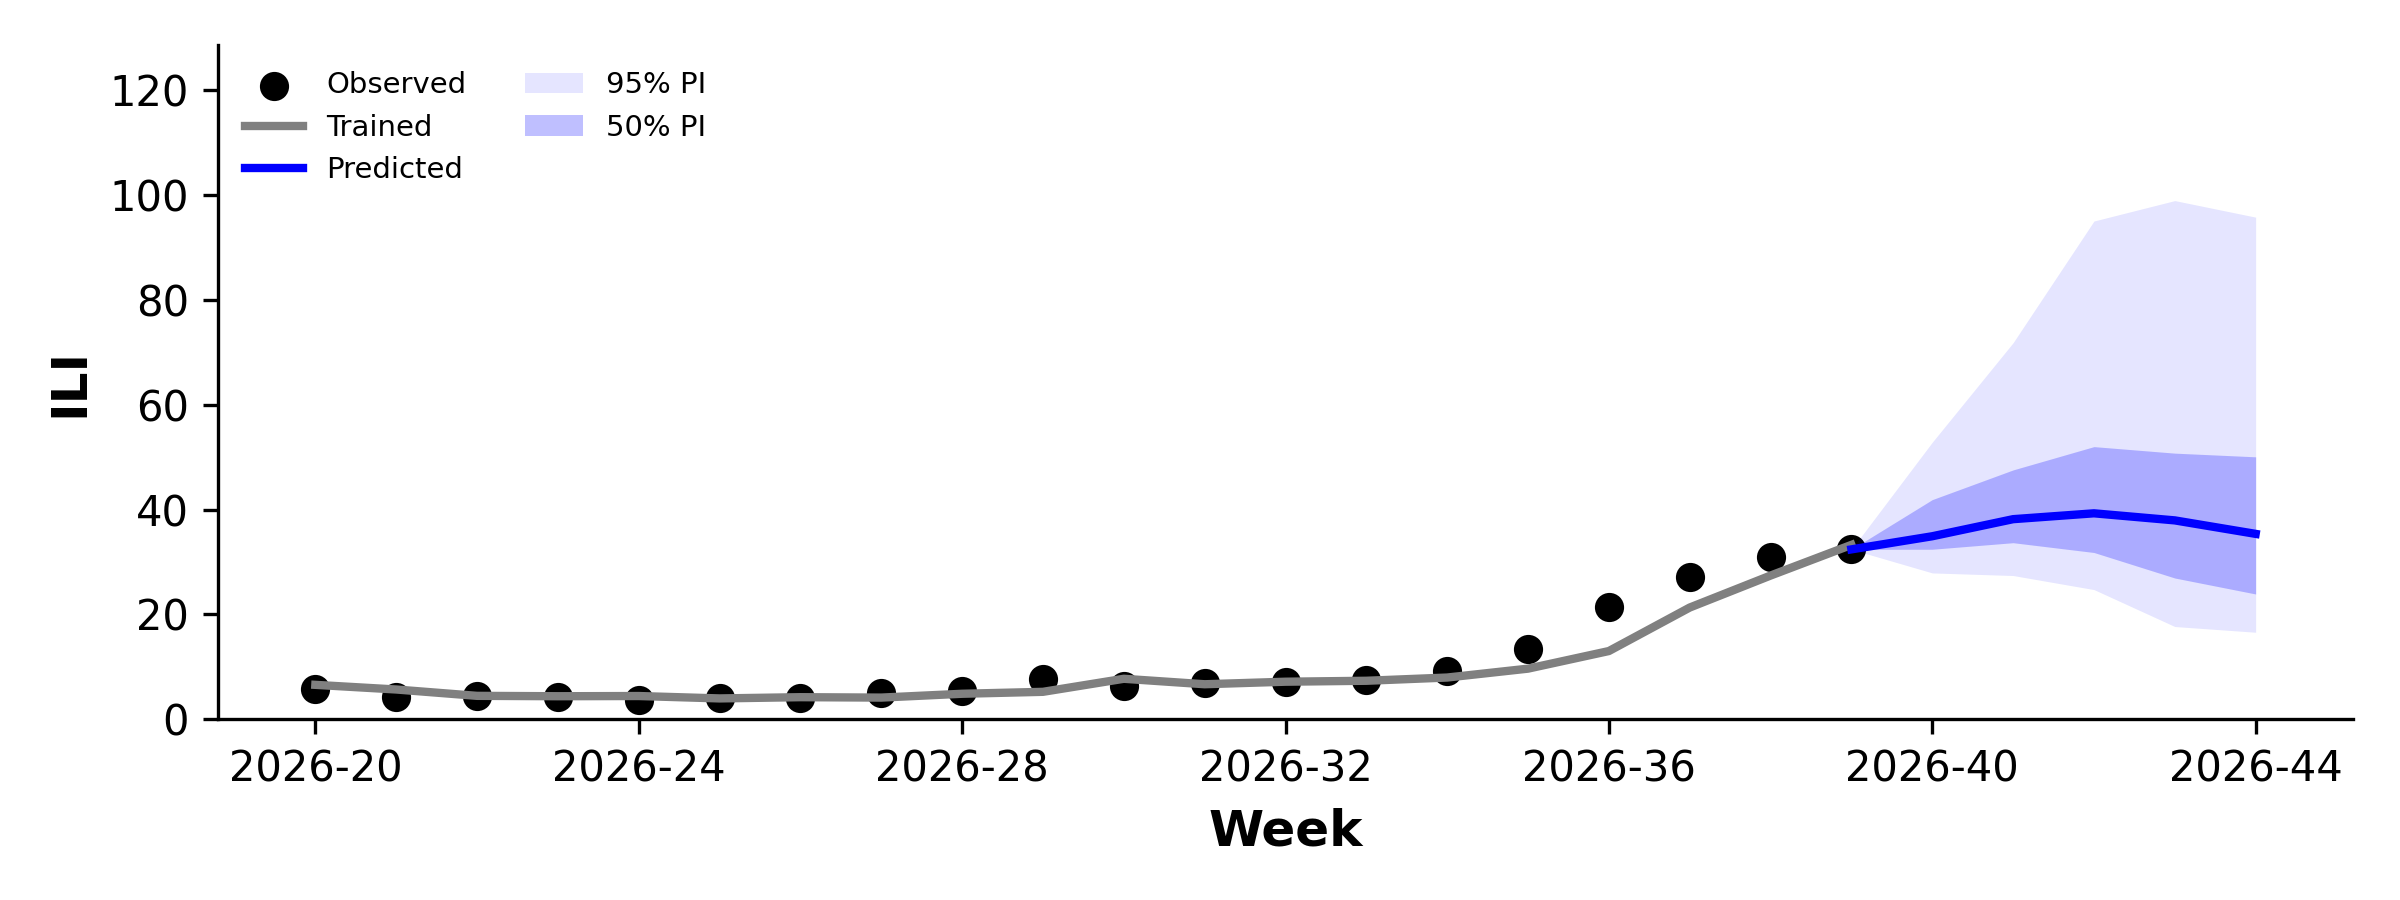

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 수정할 설정
DATA_PATH = "인플루엔자 2차 학습 데이터_아형 검출률 추가.xlsx"
RESULT_DIR = Path("forecast_results_task1c_5models_tuned")
PLOT_ORIGINS = ["1C"]
HISTORY_WEEKS = 20
SHOW_TRAINING_PREDICTION = True
SHOW_INTERVAL = True
FIGSIZE = (8, 3)
DPI = 300
LINEWIDTH = 2

# 실제 데이터와 저장된 예측값
data = pd.read_excel(DATA_PATH)
data = data.sort_values("년주").reset_index(drop=True)
predictions = pd.read_csv(RESULT_DIR / "predictions.csv", dtype={"origin": str})

# 선택된 모델과 가중치
weights_table = pd.read_csv(RESULT_DIR / "ensemble_weights.csv")
ensemble_weights = dict(zip(weights_table["model"], weights_table["ensemble_weight"]))

# 튜닝에서 선택된 설정으로 회색선을 계산
search_results = pd.read_csv(RESULT_DIR / "hyperparameter_search.csv")
selected_setting = search_results.sort_values("validation_WIS_diagnostic", kind="stable").iloc[0]
selected_leaf = int(selected_setting["min_samples_leaf"])
selected_features = float(selected_setting["max_features"])

# 기존 전역 설정 보관
previous_leaf = TREE_MIN_LEAF
previous_features = TREE_MAX_FEATURES

# 기점별 그래프
for label in PLOT_ORIGINS:
    pred = predictions.loc[predictions["origin"] == label].sort_values("horizon").copy()

    if pred.empty:
        print(f"{label}: 저장된 예측값이 없습니다.")
        continue

    origin_week = str(pred["origin_week"].iloc[0])
    origin = int(origin_week.replace("-", ""))
    train = data.loc[data["년주"] <= origin].copy()
    n = min(HISTORY_WEEKS, len(train))
    history_x = np.arange(-n + 1, 1)
    future_x = pred["horizon"].to_numpy(int)
    training_values = train["ILI"].iloc[-n:].to_numpy(float)
    last_value = training_values[-1]
    median = pred["q0.5"].to_numpy(float)
    lower = pred["q0.025"].to_numpy(float)
    upper = pred["q0.975"].to_numpy(float)
    lower_50 = pred["q0.25"].to_numpy(float)
    upper_50 = pred["q0.75"].to_numpy(float)

    # 목표 주차의 실제값이 공개된 경우 자동 반영
    actual_lookup = data.set_index("년주")["ILI"]
    target_codes = pred["target_week"].astype(str).str.replace("-", "", regex=False).astype(int)
    actual = actual_lookup.reindex(target_codes).to_numpy(float)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    # 검정: 실제 학습 데이터
    ax.scatter(history_x, training_values, color="black", label="Observed")

    # 회색: 학습 구간의 rolling 1주 예측
    fitted_train = None

    if SHOW_TRAINING_PREDICTION:
        cache_path = RESULT_DIR / f"training_predictions_{label}_leaf{selected_leaf}_features{selected_features:g}_n{n}.csv"
        history_weeks = train["년주"].iloc[-n:].to_numpy(int)

        if cache_path.exists():
            saved_training = pd.read_csv(cache_path)
            fitted_train = saved_training.set_index("year_week")["prediction"].reindex(history_weeks).to_numpy(float)

        else:
            fitted_train = np.full(n, np.nan)
            TREE_MIN_LEAF = selected_leaf
            TREE_MAX_FEATURES = selected_features

            try:
                for i, position in enumerate(range(len(train) - n, len(train))):
                    prefix = train.iloc[:position].copy()

                    if len(prefix) < 18:
                        continue

                    point_predictions = train_predict(prefix, candidate_names=list(ensemble_weights))
                    fitted_train[i] = sum(weight * float(np.expm1(point_predictions[name][0])) for name, weight in ensemble_weights.items())

                saved_training = pd.DataFrame({"year_week": history_weeks, "prediction": fitted_train})
                saved_training.to_csv(cache_path, index=False)

            finally:
                TREE_MIN_LEAF = previous_leaf
                TREE_MAX_FEATURES = previous_features

        ax.plot(history_x, fitted_train, color="gray", linestyle="-", linewidth=LINEWIDTH, label="Trained")

    # 빨강: 예측 구간의 실제 데이터
    if np.isfinite(actual).any():
        actual_mask = np.isfinite(actual)
        ax.scatter(np.r_[0, future_x[actual_mask]], np.r_[last_value, actual[actual_mask]], color="red", label="Observed test")

    # 파랑: 최종 예측값
    ax.plot(np.r_[0, future_x], np.r_[last_value, median], color="blue", linestyle="-", linewidth=LINEWIDTH, label="Predicted")

    # 95% 및 50% 예측구간
    if SHOW_INTERVAL:
        interval_x = np.r_[0, future_x]
        interval_lower = np.r_[last_value, lower]
        interval_upper = np.r_[last_value, upper]
        interval_lower_50 = np.r_[last_value, lower_50]
        interval_upper_50 = np.r_[last_value, upper_50]
        ax.fill_between(interval_x, interval_lower, interval_upper, color="blue", alpha=0.10, linewidth=0, label="95% PI")
        ax.fill_between(interval_x, interval_lower_50, interval_upper_50, color="blue", alpha=0.25, linewidth=0, label="50% PI")

    # x축 주차 표시
    history_labels = [f"{int(value) // 100}-{int(value) % 100:02d}" for value in train["년주"].iloc[-n:]]
    target_labels = pred["target_week"].astype(str).tolist()
    history_ticks = list(range(-n + 1, 1, 4))
    future_ticks = [future_x[0], future_x[-1]]
    ticks = history_ticks + future_ticks
    tick_labels = [history_labels[tick + n - 1] for tick in history_ticks]
    tick_labels += [target_labels[0], target_labels[-1]]

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, ha="center")

    # 축·범례
    ax.set_xlabel("Week", fontsize=12, fontweight="bold")
    ax.set_ylabel("ILI", fontsize=12, fontweight="bold")
    ax.legend(frameon=False, fontsize=7, loc="upper left", ncol=2)

    # y축 범위
    plotted_values = [training_values, median, actual]

    if SHOW_INTERVAL:
        plotted_values.append(upper)

    if fitted_train is not None:
        plotted_values.append(fitted_train)

    all_values = np.concatenate(plotted_values)
    finite_values = all_values[np.isfinite(all_values)]
    ymax = float(finite_values.max())

    ax.set_ylim(0, max(ymax * 1.30, 1))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    # 저장 및 표시
    save_path = RESULT_DIR / f"forecast_{label}_edited.png"
    fig.savefig(save_path, dpi=DPI)
    plt.close(fig)
    display(Image(filename=str(save_path)))